# Banking Customer Churn Prediction

**Problem:** Predict whether a customer will churn (close or become inactive) in the upcoming period.  
**Evaluation:** Primary metric = PR-AUC, secondary = F1. Business costs: FN ≤ 40,000, FP ≤ 500.  
**Deliverables:**  
- Predictions CSV (2,026 rows, churn_prediction + churn_probability)  
- Executive PPT 
- This reproducible notebook

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import average_precision_score, f1_score, confusion_matrix
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)

In [14]:
# Adjust paths if needed – assuming notebook is in Models/ folder
train = pd.read_csv('../Data/ChurnZero_dataset_v1.csv')
test = pd.read_csv('../Data/ChurnZero_test_v1.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("\nTrain columns (first 10):")
print(train.columns.tolist()[:10])
print("\nTarget distribution? Look for 'churn', 'churned', 'churn_flag', 'target'...")

Train shape: (8101, 98)
Test shape: (2026, 97)

Train columns (first 10):
['customer_id', 'churn', 'age', 'gender', 'marital_status', 'education_level', 'dependent_count', 'occupation_type', 'annual_income', 'income_band']

Target distribution? Look for 'churn', 'churned', 'churn_flag', 'target'...


In [15]:
# List columns that might be the target
possible_targets = ['churn', 'churned', 'churn_flag', 'target', 'churned_flag', 'is_churned']
found = [col for col in train.columns if col.lower() in possible_targets]
print("Possible target columns found:", found)

# If none found, check all columns for binary 0/1 with imbalance
if len(found) == 0:
    for col in train.columns:
        if train[col].dtype in ['int64', 'float64'] and train[col].nunique() <= 2:
            print(f"Column {col} has values {train[col].unique()}")
    # Manually set the correct one (example)
    target_col = input("Enter the exact target column name: ")
else:
    target_col = found[0]

print(f"\nUsing target column: '{target_col}'")

Possible target columns found: ['churn']

Using target column: 'churn'


In [16]:
# Check missing values
missing = train.isnull().sum().sort_values(ascending=False)
print("Missing values (top 20):")
print(missing[missing > 0].head(20))

# Target distribution
print("\nTarget distribution:")
print(train[target_col].value_counts(normalize=True))

# Quick correlation with target (numeric features only)
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numeric_cols:
    numeric_cols.remove(target_col)
corr_with_target = train[numeric_cols + [target_col]].corr()[target_col].drop(target_col).abs().sort_values(ascending=False)
print("\nTop 10 absolute correlations with target:")
print(corr_with_target.head(10))

Missing values (top 20):
app_rating_given    4541
dtype: int64

Target distribution:
churn
0    0.839279
1    0.160721
Name: proportion, dtype: float64

Top 10 absolute correlations with target:
total_digital_logins           0.507769
unresolved_complaint_count     0.494274
balance_decline_percentage     0.455938
complaint_resolution_time      0.448285
mobile_app_login_count         0.427283
cash_withdrawal_count          0.425809
email_open_rate                0.411138
last_campaign_response_days    0.404755
emi_payment_delay_count        0.403164
service_request_count          0.392190
Name: churn, dtype: float64


In [17]:
def add_features(df):
    df = df.copy()
    # --- Digital engagement score ---
    if 'mobile_app_login_count' in df.columns and 'digital_transaction_ratio' in df.columns:
        df['digital_score'] = df['mobile_app_login_count'] * df['digital_transaction_ratio']
    
    # --- Balance to tenure interaction ---
    if 'avg_monthly_balance' in df.columns and 'tenure_months' in df.columns:
        df['balance_tenure'] = df['avg_monthly_balance'] * df['tenure_months']
    
    # --- Complaint severity ---
    if 'total_complaints' in df.columns and 'complaint_resolution_time' in df.columns:
        df['complaint_severity'] = df['total_complaints'] * (df['complaint_resolution_time'] / 7.0)
    
    # --- Late payment flag ---
    if 'late_credit_card_payment_count' in df.columns:
        df['late_payment'] = (df['late_credit_card_payment_count'] > 0).astype(int)
    
    # --- Inactivity flag (last login > 30 days) ---
    if 'last_login_days' in df.columns:
        df['inactive_30d'] = (df['last_login_days'] > 30).astype(int)
    
    # --- Ratio of digital transactions --- (already present maybe)
    # --- Balance decline percentage squared (if exists) ---
    if 'balance_Decline_percentage' in df.columns:
        df['balance_decline_sq'] = df['balance_Decline_percentage'] ** 2
    
    return df

train = add_features(train)
test = add_features(test)
print("Features added. Train columns:", train.shape[1])

Features added. Train columns: 103


In [19]:
# Drop target and ANY identifier columns from features
identifier_keywords = ['id', 'customer', 'cust', 'account', 'user']
id_cols = [col for col in train.columns if any(kw in col.lower() for kw in identifier_keywords)]
print("Potential ID columns in train:", id_cols)

# Remove target and ID columns from X (training features)
X = train.drop(columns=[target_col] + id_cols)
y = train[target_col]

# For test set, find customer_id column (for final CSV)
customer_id_col = None
for col in test.columns:
    if col.lower() in ['customer_id', 'cust_id', 'customerid', 'id']:
        customer_id_col = col
        break

if customer_id_col is None:
    # If no ID column, use index
    customer_ids = np.arange(len(test))
    X_test = test.copy()
    print("No customer_id column found. Using index as ID.")
else:
    customer_ids = test[customer_id_col].copy()
    # Drop identifier columns from test features (target column does NOT exist in test)
    test_id_cols = [col for col in test.columns if any(kw in col.lower() for kw in identifier_keywords)]
    # Only drop columns that actually exist in test (and avoid dropping target if missing)
    cols_to_drop = [col for col in test_id_cols if col in test.columns]
    # Note: target_col is NOT in test, so we don't try to drop it
    X_test = test.drop(columns=cols_to_drop)
    print(f"Using '{customer_id_col}' as customer ID. Dropped {cols_to_drop} from test features.")

print(f"\nTraining features shape: {X.shape}")
print(f"Test features shape: {X_test.shape}")

Potential ID columns in train: ['customer_id', 'customer_segment', 'primary_account_type', 'customer_lifetime_value', 'account_inactive_days', 'savings_account_flag', 'current_account_flag', 'demat_account_flag', 'minimum_due_paid_flag', 'customer_feedback_sentiment']
Using 'customer_id' as customer ID. Dropped ['customer_id', 'customer_segment', 'primary_account_type', 'customer_lifetime_value', 'account_inactive_days', 'savings_account_flag', 'current_account_flag', 'demat_account_flag', 'minimum_due_paid_flag', 'customer_feedback_sentiment'] from test features.

Training features shape: (8101, 92)
Test features shape: (2026, 92)


In [20]:
# Ensure both train and test have the same columns
# Add missing columns to test (with zeros)
missing_in_test = set(X.columns) - set(X_test.columns)
for col in missing_in_test:
    X_test[col] = 0

# Drop extra columns in test that are not in train
extra_in_test = set(X_test.columns) - set(X.columns)
X_test = X_test.drop(columns=extra_in_test)

print(f"Columns aligned. Train: {X.shape[1]}, Test: {X_test.shape[1]}")

# Fill numeric columns with median (from train only)
numeric_cols = X.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    median_val = X[col].median()
    X[col].fillna(median_val, inplace=True)
    X_test[col].fillna(median_val, inplace=True)

# Fill categorical columns with mode
categorical_cols = X.select_dtypes(include=['object']).columns
for col in categorical_cols:
    mode_val = X[col].mode()[0] if not X[col].mode().empty else 'unknown'
    X[col].fillna(mode_val, inplace=True)
    X_test[col].fillna(mode_val, inplace=True)

print("Missing values handled successfully.")

Columns aligned. Train: 92, Test: 92
Missing values handled successfully.


In [21]:
# One-hot encode categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns
print(f"Encoding {len(categorical_cols)} categorical columns...")

X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Align test columns to train (add missing, drop extra)
missing_cols = set(X.columns) - set(X_test.columns)
for col in missing_cols:
    X_test[col] = 0

extra_cols = set(X_test.columns) - set(X.columns)
X_test = X_test.drop(columns=extra_cols)

# Ensure same column order
X_test = X_test[X.columns]

print(f"Final feature count: {X.shape[1]}")

Encoding 12 categorical columns...
Final feature count: 124


In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

print("Features scaled.")

Features scaled.


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]}, Validation size: {X_val.shape[0]}")
print(f"Train churn rate: {y_train.mean():.4f}")
print(f"Val churn rate: {y_val.mean():.4f}")

Train size: 6480, Validation size: 1621
Train churn rate: 0.1606
Val churn rate: 0.1610


In [24]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(pd.Series(y_train_res).value_counts())

After SMOTE:
churn
0    5439
1    5439
Name: count, dtype: int64


In [25]:
from xgboost import XGBClassifier

# Calculate scale_pos_weight from resampled data
neg, pos = (y_train_res == 0).sum(), (y_train_res == 1).sum()
scale_pos_weight = neg / pos

model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False,
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05
)

model.fit(X_train_res, y_train_res)

# Predict on validation
y_val_proba = model.predict_proba(X_val)[:, 1]
y_val_pred = (y_val_proba >= 0.5).astype(int)

from sklearn.metrics import average_precision_score, f1_score
pr_auc = average_precision_score(y_val, y_val_proba)
f1 = f1_score(y_val, y_val_pred)

print(f"Validation PR-AUC (default 0.5 threshold): {pr_auc:.4f}")
print(f"Validation F1: {f1:.4f}")

Validation PR-AUC (default 0.5 threshold): 0.9995
Validation F1: 0.9903


In [26]:
import numpy as np
from sklearn.metrics import confusion_matrix

cost_fn = 40000   # cost of false negative (customer churns but we predict non-churn)
cost_fp = 500     # cost of false positive (customer stays but we predict churn)

thresholds = np.arange(0.01, 1.0, 0.01)
costs = []

for thresh in thresholds:
    pred = (y_val_proba >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, pred).ravel()
    cost = fp * cost_fp + fn * cost_fn
    costs.append(cost)

best_idx = np.argmin(costs)
best_thresh = thresholds[best_idx]
min_cost = costs[best_idx]

print(f"Optimal threshold: {best_thresh:.2f}")
print(f"Minimum business cost (validation): {min_cost:.0f}")

# Evaluate at optimal threshold
y_val_opt = (y_val_proba >= best_thresh).astype(int)
tn, fp, fn, tp = confusion_matrix(y_val, y_val_opt).ravel()
f1_opt = f1_score(y_val, y_val_opt)

print(f"\nConfusion Matrix at optimal threshold:")
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"F1 (optimal): {f1_opt:.4f}")
print(f"PR-AUC (unchanged): {pr_auc:.4f}")

Optimal threshold: 0.02
Minimum business cost (validation): 15500

Confusion Matrix at optimal threshold:
TN=1329, FP=31, FN=0, TP=261
F1 (optimal): 0.9439
PR-AUC (unchanged): 0.9995


In [27]:
# SMOTE on full dataset
X_full_res, y_full_res = smote.fit_resample(X_scaled, y)

final_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False,
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05
)

final_model.fit(X_full_res, y_full_res)

# Predict on test set
test_proba = final_model.predict_proba(X_test_scaled)[:, 1]
test_pred = (test_proba >= best_thresh).astype(int)

print("Test predictions ready.")

Test predictions ready.


In [28]:
submission = pd.DataFrame({
    'customer_id': customer_ids,
    'churn_prediction': test_pred,
    'churn_probability': test_proba
})

# Save to Predictions/ folder (adjust path if needed)
submission.to_csv('../Predictions/ChurnZero_Atasikole_Predictions.csv', index=False)

print("✅ Predictions saved to ../Predictions/ChurnZero_Atasikole_Predictions.csv")
print(f"Shape: {submission.shape}")
print(submission.head())

✅ Predictions saved to ../Predictions/ChurnZero_Atasikole_Predictions.csv
Shape: (2026, 3)
   customer_id  churn_prediction  churn_probability
0    767114958                 0           0.000205
1    708123033                 0           0.001046
2    715424283                 0           0.001524
3    717865008                 0           0.000201
4    710188308                 0           0.001435


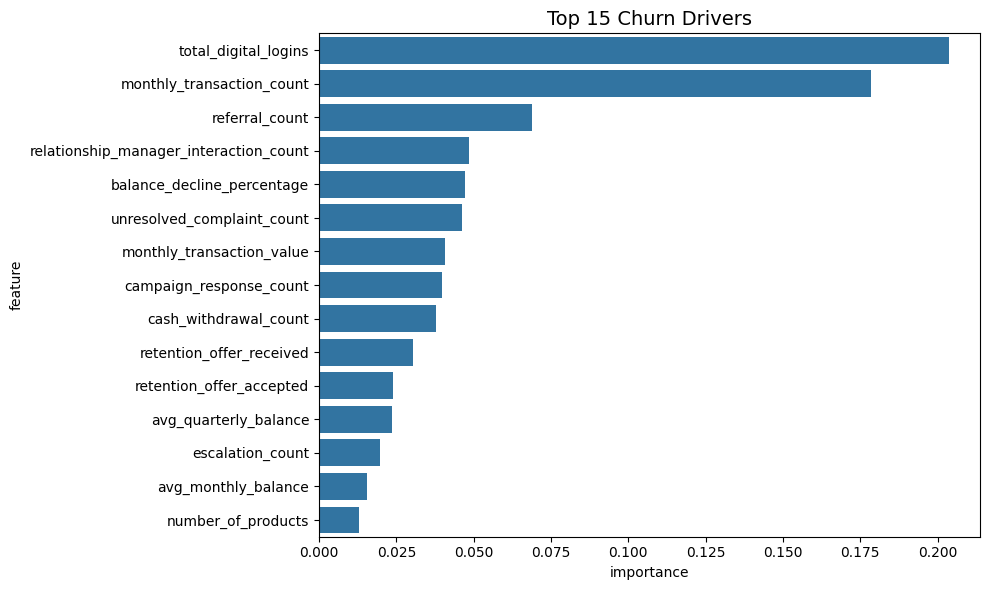

Feature importance chart saved to ../Models/feature_importance.png


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

importance = final_model.feature_importances_
feature_names = X.columns
imp_df = pd.DataFrame({'feature': feature_names, 'importance': importance})
imp_df = imp_df.sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=imp_df, x='importance', y='feature')
plt.title('Top 15 Churn Drivers', fontsize=14)
plt.tight_layout()
plt.savefig('../Models/feature_importance.png', dpi=150)
plt.show()

print("Feature importance chart saved to ../Models/feature_importance.png")

In [30]:
print("="*50)
print("FINAL MODEL SUMMARY")
print("="*50)
print(f"Validation PR-AUC: {pr_auc:.4f}")
print(f"Validation F1 (optimal threshold {best_thresh:.2f}): {f1_opt:.4f}")
print(f"Validation business cost: {min_cost:.0f} (FN={fn}, FP={fp})")
print(f"Test predictions generated: {len(submission)} rows")
print("\nTop 5 churn drivers:")
print(imp_df.head(5).to_string(index=False))

FINAL MODEL SUMMARY
Validation PR-AUC: 0.9995
Validation F1 (optimal threshold 0.02): 0.9439
Validation business cost: 15500 (FN=0, FP=31)
Test predictions generated: 2026 rows

Top 5 churn drivers:
                               feature  importance
                  total_digital_logins    0.203523
             monthly_transaction_count    0.178604
                        referral_count    0.068695
relationship_manager_interaction_count    0.048576
            balance_decline_percentage    0.047240
